# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)
# Libreria con solo 2 entradas por Columna

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum().sort_values()) # Cantidad de valores nulos
print()
print(users.isna().mean().sort_values(ascending=True)*100) # Proporción de valores nulos


user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
city           469
churn_date    3534
dtype: int64

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
reg_date       0.000
plan           0.000
city          11.725
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum().sort_values()) # Cantidad de valores nulos
print()
print(usage.isna().mean().sort_values(ascending=True)*100) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
length      17896
duration    22076
dtype: int64

id           0.000
user_id      0.000
type         0.000
date         0.125
length      44.740
duration    55.190
dtype: float64


✍️ **Comentarios**:
Analisis de valores faltanates para los Datasets 'users' y 'usage'

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
- Con respecto al analisis del Dataset 'users', se encuentra que en la colummna 'churn_date' tenemos el 88.35% de valores nulos, lo que nos indica que esos clientes aun estan activos, por lo que se le daria el manejo de que null='cliente activo'; en la culumnna  'city' contamos con el 11.72% es una proporción considerable que podría sesgar análisis geográficos, estos valores se pueden imputar con una categoría "Unknown" es más seguro que eliminar el 11% de los usuarios, adicionalmente para el propósito del proyecto no necesitamos realizar un análisis geográfico, ya que los valores para los planes móviles son iguales en los dos países registrados

- Analizando el dataset ‘usage’  los valores faltantes para la columna duration es del 55.19% y length 44.74%. Estos valores en realidad no es que sean faltantes, observando con mas detalle, cuando el cliente realiza una llamada aparece el valor de 'duration' y cuando es un mensaje aparece el valor de 'lenght, por lo que si sumo los dos porcentajes corresponde al 99.93% de valores correctos y solo el 0.07%.  Se podría virificar si el type del registro justifica el nulo (por ejemplo, si es un mensaje de texto, la duración es lógicamente 0). Si son llamadas, se podría imputar usando la mediana de ese usuario específico o la mediana general del tipo de servicio para no sesgar con valores extremos. Para la columna ‘date’ solo son 50 registros los que aparecen como nulos, por lo que se podría dejar como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [13]:
# explorar columnas numéricas de users
users['age'].isin([-999]).sum()

55

- La columna `user_id` no contiene valores nullos ni sentineles, por lo que podemos trabajar con ella sin inconvenientes
- La columna `age` contiene valores inusuales o sentineles como -999, teniendo un total de 55 entradas con este valor. Promedio de edad de 34 años, con un maximo de edad de 79 años. 

In [14]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration','length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: segun los valores observados se tiene congruencia con el numero total de entradas. El hecho de que la mediana de 'user_id' esté cerca del centro del rango indica que los datos de uso están bien distribuidos entre toda la base de usuarios y no concentrados en unos pocos. 
- Las columnas 'duration' y 'lenght': El conteo de duration (17,924) y length (22,104), al sumarlos se obtiene 40,028. Dado que el total de registros es de 40,000, esto ratifica que casi cada fila tiene o uno o lo otro. Hay una ligera superposición de 28 registros que vale la pena mirar después, pero la lógica de "llamada vs. mensaje" se sostiene perfectamente.
- Columna 'duration': El promedio es de 5.20 minutos, pero la mediana (50%) es de 3.50 minutos.Hay un sesgo a la derecha. La mayoría de las llamadas son cortas, pero hay algunas muy largas que "inflan" el promedio.El máximo es de 120 minutos (2 horas exactas). La desviación estándar (6.84) es mayor que el promedio, lo que indica que hay mucha variabilidad en cuánto duran las llamadas de los usuarios
- Columna 'length': El promedio (52.12) y la mediana (50.00) están muy cerca. Esto sugiere una distribución mucho más simétrica y predecible que las llamadas. Se puede observar una anomalía con el valor máximo, el cual es de 1,490, mientras que el 75% de los datos llega apenas a 64. Ese 1,490 está extremadamente lejos del resto. Podría ser un mensaje masivo, un error de sistema o un comportamiento atípico que se debería revisar, ya que podría distorsionar los modelos estadísticos


In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [16]:
# explorar columnas categóricas de users
columnas_user = ['city']
users[columnas_user].value_counts()

city    
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
dtype: int64

- La columna `city`, se confirma que hay un total de 469 usuaros sin ciudad asignada, se tienen 7 ciudades registradas observando que el valor que con mas frecuencia se repite(808) es Bogotá, siendo esta la ciudad principal. Existen 96 entradas con '?'
- La columna `plan`, confirmamos que solo existen dos tipos de plan movil, predominando el plan Basico, 2595 (el 64.8%) están en este plan, lo que sugiere que el dataset está inclinado hacia usuarios que buscan economía o tienen un consumo moderado. El reto para el negocio suele ser el upselling (pasar usuarios de Básico a Premium)

In [17]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` El valor más frecuente es text, con una frecuencia de 22,092. Lo que indica que 17,908 registros son de tipo call. Se puede deducir que el 55.2% de las interacciones de los usuarios son a través de mensajes de texto, mientras que el 44.8% de usuarios optan por las llamadas.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- - La columna `age` contiene valores inusuales o sentineles como -999, teniendo un total de 55 entradas con este valor, ya que la desviación estándar (std) es de 123.23, es una valor muy alto  variable de edad, el promedio (mean) bajó a 33.7, mientras que la mediana (50%) es de 47. Optare por convertir los valores sentineles -999 en valores nulos y luego imputar con la mediana.
  - La columna `city`, se confirma que hay un total de 469 usuaros sin ciudad asignada, se tienen 7 ciudades registradas observando que el valor que con mas frecuencia se repite(808) es Bogotá, siendo esta la ciudad principal, debido a que no se realizara un analisi geografico, se podria estos valores se pueden imputar con una categoría "Unknown"   

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [20]:

# Revisar los años presentes en `reg_date` de users
print("Conteo de registros por año:")
print(users['reg_date'].dt.year.value_counts().sort_index())


Conteo de registros por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se observa que se tienen 40 registros del año 2026, los cuales no deberian estar en el dataset, estos valores pueden ser eliminados ya que representan solo el 1% de toda la data, o se podria convertrlos a valores nulos

In [21]:
# Revisar los años presentes en `date` de usage
print("Conteo de registros por año:")
print(usage['date'].dt.year.value_counts().sort_index())

Conteo de registros por año:
2024.0    39950
Name: date, dtype: int64


En `date`, se confirma que hacen falta 50 datos de entrada para la columna 'date', y la data solo esta registrada para el año 2024
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---
## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_is_null'] = usage['duration'].isnull()
check_duration = usage.groupby('type')['duration_is_null'].mean() * 100
print("Porcentaje de nulos en 'duration' por tipo:")
print(check_duration)

Porcentaje de nulos en 'duration' por tipo:
type
call     0.000000
text    99.927576
Name: duration_is_null, dtype: float64


In [28]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_is_null'] = usage['length'].isnull()
check_length = usage.groupby('type')['length_is_null'].mean() * 100
print("Porcentaje de nulos en 'length' por tipo:")
print(check_length)

Porcentaje de nulos en 'length' por tipo:
type
call    99.932991
text     0.000000
Name: length_is_null, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`, Los datos confirman que la falta de información son un caso de Missing at Random (MAR). Existe una relación de dependencia casi perfecta, en duration, los nulos aparecen prácticamente solo cuando el tipo es text (99.92%) y en length, los nulos aparecen prácticamente solo cuando el tipo es call (99.93%). Esto demuestra que la variable type explica perfectamente por qué falta el dato en las otras columnas. Por lo anterior, estos valores se dejaran como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Renombrar columnas
usage_agg.columns = [
    "user_id", 
    "cant_mensajes", 
    "cant_llamadas", 
    "cant_minutos_llamada"
]
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left") 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left") 
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               4000 non-null   int64         
 1   first_name            4000 non-null   object        
 2   last_name             4000 non-null   object        
 3   age                   4000 non-null   float64       
 4   city                  3435 non-null   object        
 5   reg_date              3960 non-null   datetime64[ns]
 6   plan                  4000 non-null   object        
 7   churn_date            466 non-null    object        
 8   cant_mensajes         3999 non-null   float64       
 9   cant_llamadas         3999 non-null   float64       
 10  cant_minutos_llamada  3999 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 375.0+ KB


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [34]:
# Resumen estadístico de las columnas numéricas
users_2024 = user_profile[user_profile['reg_date'].dt.year == 2024].copy()
cols_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
resumen_2024 = users_2024[cols_numericas].describe()
print(resumen_2024)

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  1330.000000    1330.000000    1330.000000           1330.000000
mean     48.425564       5.500000       4.557143             24.126669
std      17.962865       2.382293       2.140329             19.458620
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.332500
50%      48.000000       5.000000       4.000000             20.325000
75%      64.000000       7.000000       6.000000             32.542500
max      79.000000      16.000000      13.000000            155.690000


In [37]:
# Distribución porcentual del tipo de plan
plan_distribucion = user_profile['plan'].value_counts(normalize=True) * 100
print("Distribución de usuarios por plan (en %):")
print(plan_distribucion.map("{:.2f}%".format))

Distribución de usuarios por plan (en %):
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

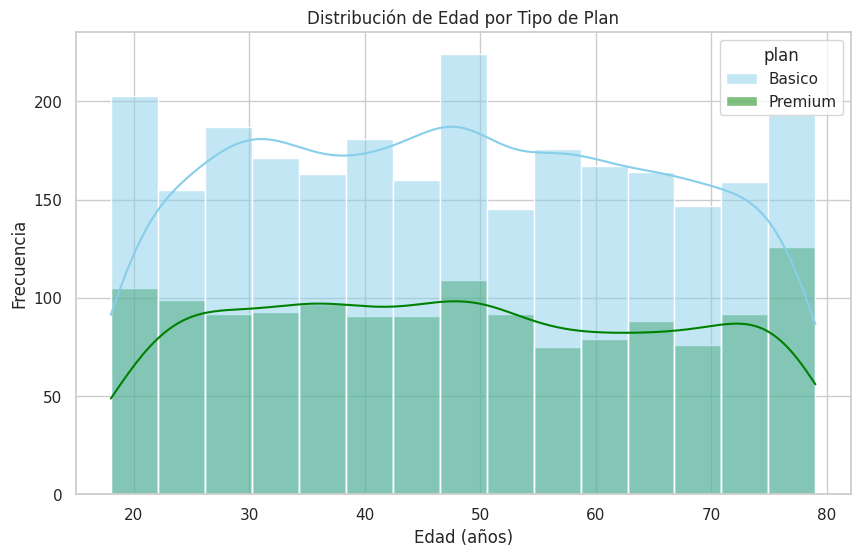

In [38]:
# Histograma para visualizar la edad (age)
# Configuramos el estilo general de las gráficas
sns.set_theme(style="whitegrid")
colores = ['skyblue', 'green']
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', bins=15, palette=colores, kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Lo primero que se puede observar en el histograma para la distribución de edad por tipo de plan es que la edad no parece ser un factor determinante para elegir entre un plan u otro. Las barras y las líneas de densidad son bastante "planas" a lo largo de todo el eje X (desde los 18 hasta los 80 años). No se tiene un segmento de edad específico que prefiera el plan Premium. Tanto jóvenes de 20 años como adultos de 70 consumen ambos planes en proporciones similares. El Plan Básico es el producto principal de la empresa. Independientemente de la edad, la mayoría de los usuarios opta por la opción más económica o estándar.

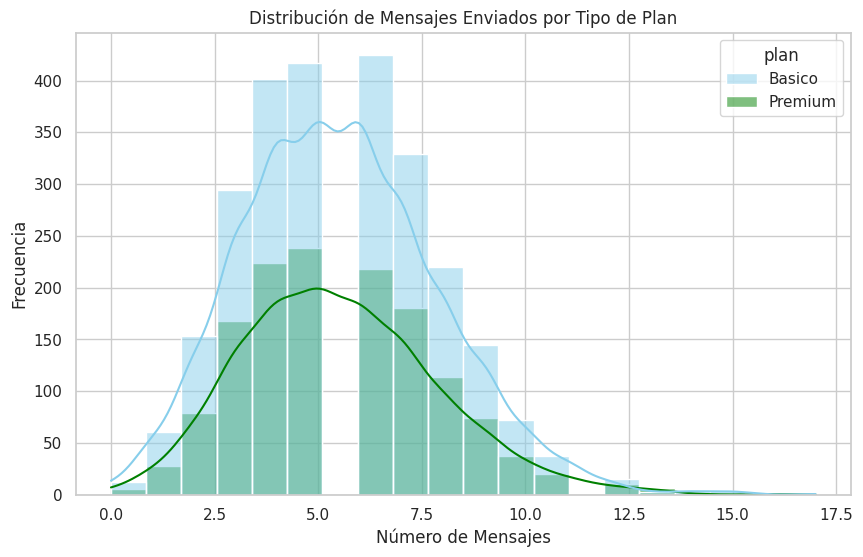

In [39]:
# Histograma para visualizar la cant_mensajes
# Configuramos el estilo general de las gráficas
sns.set_theme(style="whitegrid")
colores = ['skyblue', 'green']
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=20, palette=colores, kde=True)
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Número de Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La grafica para la distribución de mensajes enviador por tipo de plan tiene forma de campana (Normal), ambas distribuciones son bastante simétricas, centradas alrededor de los 4 a 7 mensajes. Curiosamente, los usuarios del plan Premium no envían significativamente más mensajes que los del Básico. Las curvas "viajan" juntas. El mensaje de texto parece ser un servicio de uso estándar. No es el factor que motiva a un usuario a pagar el plan Premium, ya que el volumen de envío es bajo para ambos grupos.

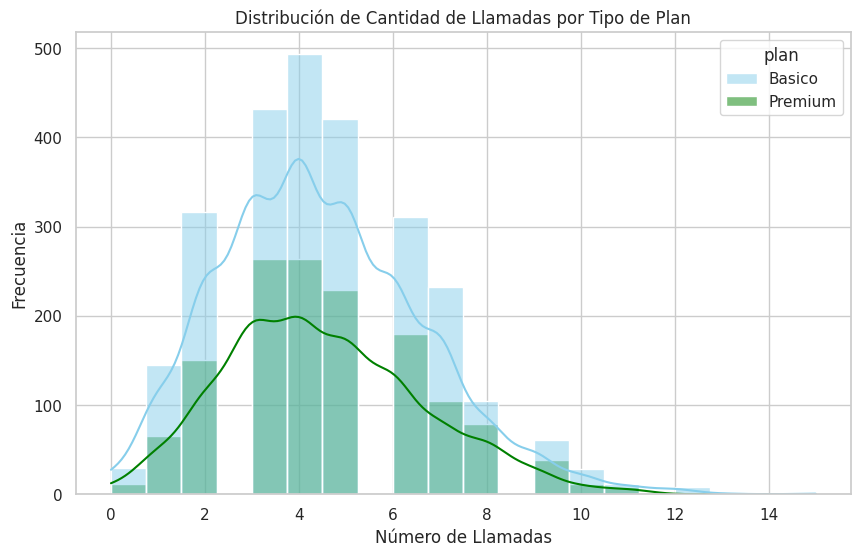

In [40]:
# Histograma para visualizar la cant_llamadas
# Configuramos el estilo general de las gráficas
sns.set_theme(style="whitegrid")
colores = ['skyblue', 'green']
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=20, palette=colores, kde=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de cantidad de llamadas se concentra en el centro, la mayoría de los usuarios realiza entre 2 y 6 llamadas, hay una presencia masiva de usuarios del plan básico realizando una cantidad moderada de llamadas (el pico azul en 4 llamadas es muy alto). Se observa que muy pocos usuarios superan las 10 llamadas. Esto sugiere que el servicio se usa para comunicaciones puntuales y no necesariamente para uso comercial o intensivo.

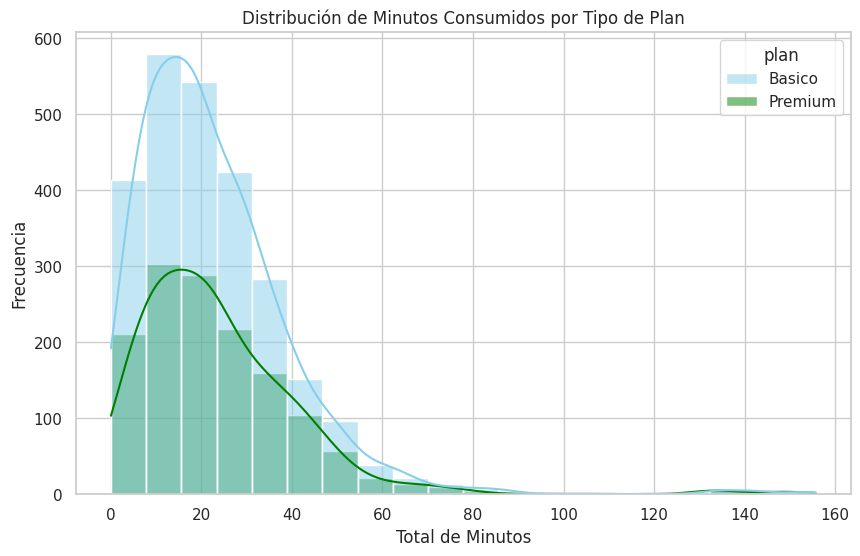

In [41]:
# Histograma para visualizar la cant_minutos_llamada
# Configuramos el estilo general de las gráficas
sns.set_theme(style="whitegrid")
colores = ['skyblue', 'green']
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=colores, kde=True)
plt.title('Distribución de Minutos Consumidos por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- El histograma para  la Distribución de Minutos Consumidos muestra un sesgo a la Derecha (Positive Skew), la mayoría consume pocos minutos (entre 10 y 30), pero hay una "cola" larga hacia la derecha.  Aunque hay menos usuarios Premium, su curva (verde) se mantiene proporcionalmente más alta conforme avanzamos hacia los 40-60 minutos en comparación con su propio volumen, tambien se observan algunos registros que llegan hasta los 140-160 minutos. Estos son tus "Heavy Users". Como conlusion, el consumo de minutos es la variable que más "estira" la distribución, es probable que los usuarios que se pasan de los 50 minutos sean los mejores candidatos para el plan Premium

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

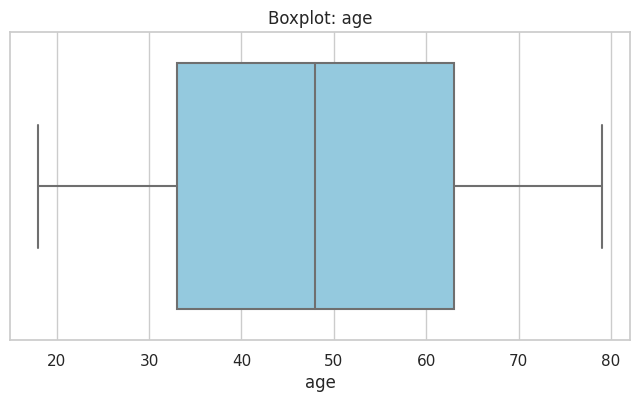

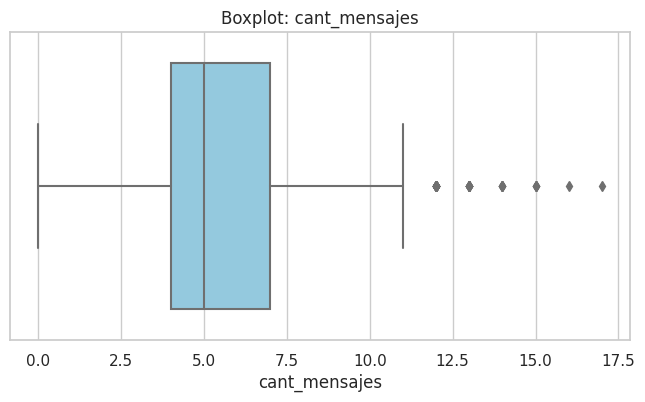

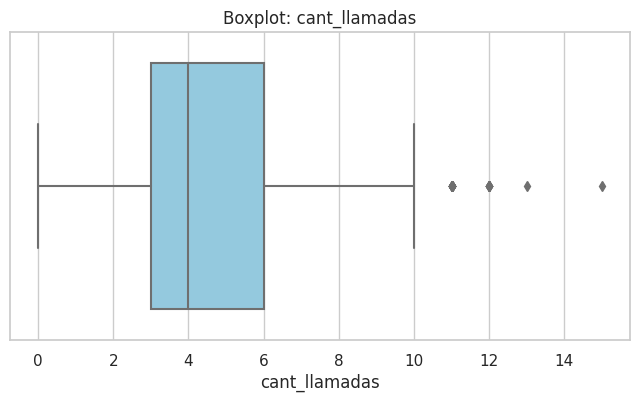

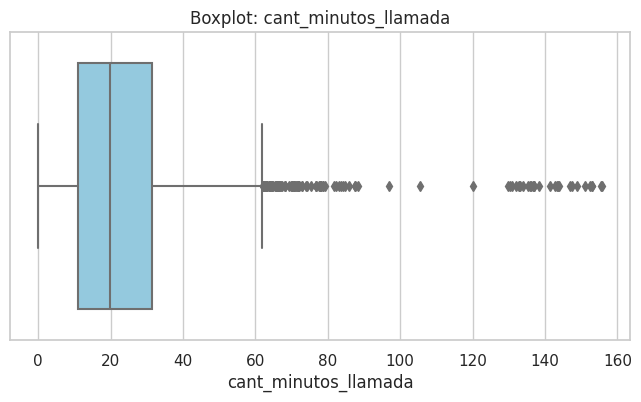

In [42]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: No requiere limpieza. Es una variable demográfica estable
- cant_mensajes: Outliers Moderados, vemos unos 6 o 7 puntos después del bigote superior (entre 12 y 17 mensajes). La mayoría de los usuarios envía entre 4 y 7 mensajes (la caja es pequeña).  Estos valores atípicos son usuarios que usan el SMS un poco más de lo normal, pero no son cifras alarmantes. Es un comportamiento natural de "uso ligero vs. uso moderado".
- cant_llamadas: Presencia de Outliers, hay 4 puntos claramente identificados entre 11 y 15 llamadas, la mediana está en 4 llamadas. Quienes hacen 15 llamadas están realizando casi 4 veces más eventos que el usuario promedio. Estos usuarios podrían ser pequeños negocios o personas que coordinan muchas actividades por voz. Son pocos, pero consistentes.
- cant_minutos_llamada: Outliers Críticos, hay una gran cantidad de puntos que se extienden desde los 60 hasta casi los 160 minutos, la caja está muy cargada hacia la izquierda (pocos minutos), pero los outliers se disparan hacia la derecha. aquí estarían los "Heavy Users", mientras que el usuario promedio habla 20 minutos, tienes un segmento que habla 150 minutos.

In [46]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Variable: {col}")
    print(f"Límite Superior (IQR): {limite_superior:.2f}")
    print(f"Valor Máximo Real: {user_profile[col].max():.2f}")

Variable: cant_mensajes
Límite Superior (IQR): 11.50
Valor Máximo Real: 17.00
Variable: cant_llamadas
Límite Superior (IQR): 10.50
Valor Máximo Real: 15.00
Variable: cant_minutos_llamada
Límite Superior (IQR): 61.86
Valor Máximo Real: 155.69


In [49]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener outliers. El límite superior es 11.50 y el máximo real es 17.00, aunque 17.00 es técnicamente un outlier, la diferencia es pequeña. En un servicio de telefonía, enviar 17 mensajes en un periodo de uso no es un comportamiento errático ni imposible. Representa a un usuario un poco más activo de lo normal, pero sigue siendo un dato valioso para entender el techo de consumo de este servicio.
- cant_llamadas: mantener o no outliers, porqué? Mantener outliers. El límite es 10.50 y el máximo es 15.00, es una situación muy similar a la de los mensajes. Un usuario que realiza 15 llamadas no está rompiendo ninguna lógica de negocio. Es un volumen perfectamente posible para un cliente real, eliminar estos datos reduciría artificialmente la variabilidad de la muestra sin ganar precisión real en el análisis.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener outliers. El límite es 61.86 pero el máximo se dispara hasta 155.69, este valor es más del doble del límite superior y casi 7 veces el promedio (media = 23.31). Estos clientes pueden continuar siendo catalogados como  "Heavy Users", en telecomunicaciones, estos no son errores de captura, son tus clientes más rentables o los que más probablemente están pagando cargos excedentes. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [50]:
# Crear columna grupo_uso
# Definir las condiciones y los resultados para el Grupo de Uso
condiciones_uso = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
opciones_uso = ['Bajo uso', 'Uso medio']

# Creamos la columna; el 'Alto uso' se asigna por defecto si no cumple las anteriores
user_profile['grupo_uso'] = np.select(condiciones_uso, opciones_uso, default='Alto uso')

In [51]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [52]:
# Crear columna grupo_edad
# Definir las condiciones y los resultados para el Grupo de Edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

opciones_edad = ['Joven', 'Adulto']

# Creamos la columna; 'Adulto Mayor' se asigna por defecto (>= 60)
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

In [53]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

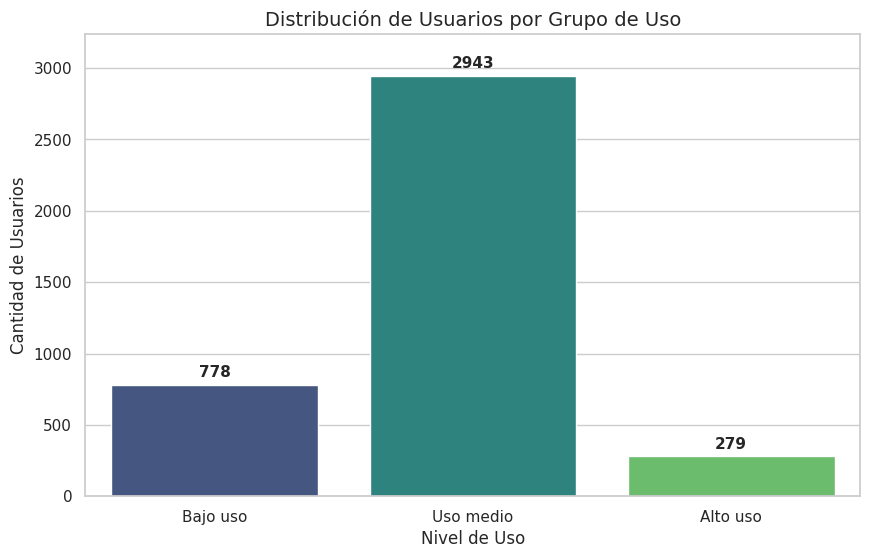

In [59]:
# Visualización de los segmentos por uso
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Generar el countplot
ax = sns.countplot(data=user_profile, x='grupo_uso', 
                   order=['Bajo uso', 'Uso medio', 'Alto uso'], 
                   palette='viridis')

# Agregar etiquetas
for p in ax.patches:
    # Obtenemos la altura de la barra para saber el valor y la posición
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# Títulos y ajustes finales
plt.title('Distribución de Usuarios por Grupo de Uso', fontsize=14)
plt.xlabel('Nivel de Uso', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Ajustar el límite superior para que no se corten los números
plt.ylim(0, user_profile['grupo_uso'].value_counts().max() * 1.1)

plt.show()
    


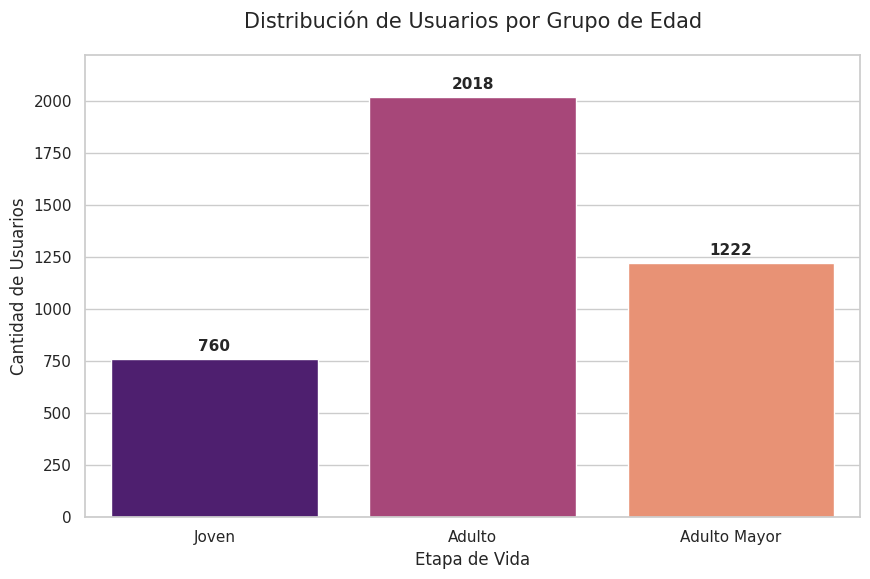

In [60]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Generar el countplot para grupo_edad
# Usamos el orden lógico: Joven -> Adulto -> Adulto Mayor
ax = sns.countplot(data=user_profile, x='grupo_edad', 
                   order=['Joven', 'Adulto', 'Adulto Mayor'], 
                   palette='magma')

# 3. Agregar etiquetas de valor sobre cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# Títulos y etiquetas de los ejes
plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=15, pad=20)
plt.xlabel('Etapa de Vida', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Ajustar el límite superior del eje Y para que no se corten los números
max_count = user_profile['grupo_edad'].value_counts().max()
plt.ylim(0, max_count * 1.1)

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Originalmente, los datasets presentaban inconsistencias que requerían atención para asegurar la validez del análisis:
- Valores sentinels en edad: Se detectó el valor -999 en la columna age del dataset de usuarios, afectando a 55 filas (1.38%). Este es un error de registro que debe ser tratado para no sesgar los promedios de edad.
- Registros geográficos incompletos: La columna city tenía un 11.72% de valores nulos y además 96 registros con el carácter "?". Aunque representaba un reto para análisis locales, se determinó que no afectaba el análisis de rentabilidad actual ya que los planes son iguales en todas las regiones
- Estructura de uso: El dataset usage presentaba nulos masivos en duration (55.19%) y length (44.74%). Sin embargo, se identificó que esto no es un error, sino una estructura donde los nulos de una columna corresponden a los registros de la otra (llamadas vs. mensajes), cubriendo el 99.93% de la actividad real.


🔍 **Segmentos por Edad**
- Preferencia de Plan: El 64.8% de los usuarios (2,595) prefiere el plan Básico, mientras que el resto opta por el Premium.
- •	Perfil de Edad: La edad promedio es de 34 años, aunque la mediana (47 años) y el máximo (79 años) sugieren una base de clientes madura con un grupo significativo de usuarios jóvenes que bajan el promedio.


📊 **Segmentos por Nivel de Uso**
- •	Comportamiento de Consumo: El uso de mensajes es simétrico y predecible (mediana de 50 mensajes). En contraste, las llamadas muestran un sesgo, la mayoría son cortas (mediana 3.5 min), pero existe un grupo que realiza llamadas muy extensas.
- Usuarios del Plan Premium: Representan la mayor fuente de ingresos estables por cuota mensual (25 USD vs 12 USD).
- "Heavy Users" del Plan Básico: Aquellos que superan los límites de 100 min o 5GB. Dado que el costo por GB extra es de 1.2 USD (más caro que en el Premium), estos usuarios generan ingresos adicionales por excedentes que pueden superar el costo de una suscripción Premium.
- Mensajería Masiva: Se encontró un registro de 1,490 mensajes, una cifra extremadamente lejana al percentil 75 que es apenas de 64 mensajes. Esto podría implicar uso comercial/spam o errores en el sistema de medición.
- llamadas de larga duracion: El máximo detectado fue de 120 minutos (2 horas exactas). Para el negocio, esto representa una alta ocupación de red por un solo usuario, lo cual debe monitorearse para evitar congestión si el patrón se repite en ciertos horarios.

➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Migración dirigida (Upselling): Identificar a los usuarios del plan Básico que pagan frecuentemente por GB extras y ofrecerles el plan Premium resaltando que el costo por GB es 16% más bajo (1.0 USD vs 1.2 USD).
- Nuevo "Plan Intermedio": Existe un salto grande entre los 5GB del plan Básico y los 20GB del Premium. Crear un plan de 10-12 GB capturaría a los usuarios que se sienten limitados en el Básico pero no necesitan el volumen del Premium.
- Control de Uso Extremo: Implementar una política de "Uso Justo" para mensajes que superen los 1,000 registros, con el fin de mitigar el impacto de los outliers detectados.
- Saneamiento de Base de Datos: Corregir los procesos de captura de edad para eliminar los valores "-999" y mejorar la precisión de futuras campañas segmentadas por edad.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`